## 1. Carregamento e Limpeza dos Dados

In [26]:
!pip install kagglehub -q

In [27]:
# versões utilizadas neste notebook
# pra reproduzir o ambiente, descomente e execute:

# !pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 \
#   matplotlib==3.10.0 seaborn==0.13.2 kagglehub==1.0.0


In [28]:
import kagglehub
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [29]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_path)
df.head(10)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [30]:
# vamo verificar os tipos das colunas pra entender melhor o dataset
df.dtypes

# TotalCharges deveria ser um float, mas tá como object
# vamo converter pro tipo certo e transformar os espaços em branco em NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [31]:
# o costumerID não tem nenhum valor preditivo pro modelo, ele é só um identificador
# vamo remover essa coluna, então

df.drop(columns=['customerID'], inplace=True)
df.head(10)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [32]:
# vamo verificar se tem alguma duplicata
print(f"Duplicatas: {df.duplicated().sum()}")

# e tbm visualizar as linhas duplicadas pra entender o que são
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)


Duplicatas: 22


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [33]:
# vamo remover as duplicadas pq linhas idênticas em todas as colunas não agregam informação

print(f"Shape antes da remoção das duplicatas: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape após remoção das duplicatas: {df.shape}")


Shape antes da remoção das duplicatas: (7043, 20)
Shape após remoção das duplicatas: (7021, 20)


In [34]:
# vamo verificar tbm a presença de valores nulos
df.isnull().sum()


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [35]:
# tivemos 11 valores ausentes na coluna que a gente transformou o tipo (TotalCharges)
# então vamo inspecionar essas linhas com NaN pra avaliar a situação

df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


'tenure' indica a quantidade de meses que o cliente está com a empresa e o 'MonthlyCharges' indica a cobrança mensal desse cliente. como resultado dessa interação, a gente tem o 'TotalCharges'.

sabendo disso, dá pra gente entender que esses valores ausentes em 'TotalCharges' existem, justamente, pq esses clientes entraram e saíram sem gerar histórico, sem nem completar o primeiro mês de cobrança.

sendo assim, a gente pode apenas remover essas linhas sem nenhum impacto (até pq só são 11 linhas em um dataset com mais de 7 mil).

In [36]:
# vamo remover as linhas com NaN

df = df.dropna(subset=['TotalCharges'])


In [37]:
# vamo binarizar o target pro código da EDA ficar limpo e direto
#-> 0 = cliente que ficou; 1 = cliente que cancelou.

df['Churn'] = (df['Churn'] == 'Yes').astype(int)


## 2. Análise Exploratória (EDA)

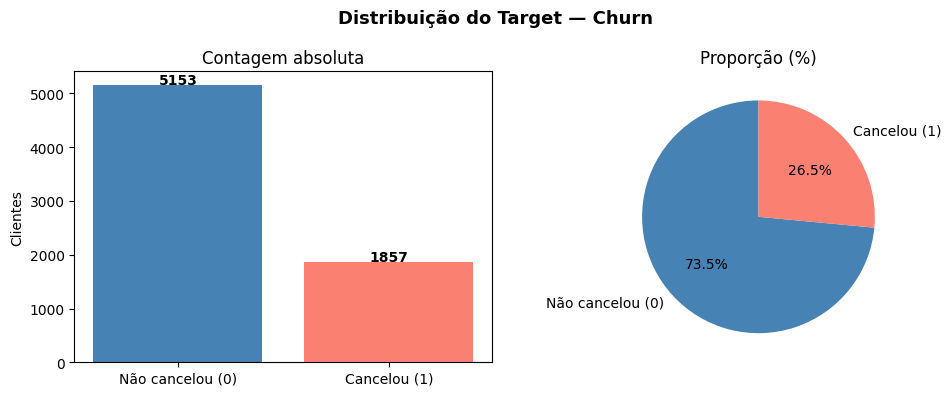

Total: 7010 clientes | Churn: 1857 (26.5%) | Não-churn: 5153 (73.5%)


In [38]:
# vamo visualizar a distribuição do target pra saber quantos % cancelaram
# vamo usar um gráfico duplo pra deixar bem evidente o balanceamento das classes

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# vamo incluir uma contagem absoluta
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Não cancelou (0)', 'Cancelou (1)'], churn_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Contagem absoluta')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# e uma proporção percentual
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=['Não cancelou (0)', 'Cancelou (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporção (%)')

plt.suptitle('Distribuição do Target — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total: {len(df)} clientes | Churn: {churn_counts[1]} ({churn_pct[1]:.1f}%) | Não-churn: {churn_counts[0]} ({churn_pct[0]:.1f}%)")


o dataset é desbalanceado (26%/74%). isso reflete a realidade de negócio, onde um churn de 26% já é alto na prática. mas o modelo tende a priorizar a classe majoritária durante o treino, ignorando os casos de churn. então, um modelo "burro" que sempre prevê "não cancela" acerta 74% das vezes.

sendo assim, nesse caso, a acurácia vira uma métrica inútil aqui. vamo usar alguma técnica de balanceamento durante a modelagem e usar F1 e Recall como métricas principais na hora da análise, já que o custo de não detectar um cliente que vai cancelar (falso negativo) é maior do que acionar um cliente que ficaria de qualquer forma (falso positivo).

In [39]:
# vamo avaliar as estatísticas descritivas tanto das variáveis numéricas quanto das categóricas

print("Variáveis numéricas")
display(df.describe().T)

print("\nVariáveis categóricas")
display(df.describe(include='object').T)


Variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
Churn,7010.0,0.264907,0.441315,0.00,0.0000,0.000,1.0000,1.00



Variáveis categóricas


,count,unique,top,freq
gender,7010,2,Male,3535
Partner,7010,2,No,3617
Dependents,7010,2,No,4911
PhoneService,7010,2,Yes,6330
MultipleLines,7010,3,No,3363
InternetService,7010,3,Fiber optic,3090
OnlineSecurity,7010,3,No,3489
OnlineBackup,7010,3,No,3079
DeviceProtection,7010,3,No,3086
TechSupport,7010,3,No,3464


a gente consegue colher algumas informações a partir das estatísticas descritivas. primeiro sobre as numéricas:
- apesar de SeniorCitizen aparecer como uma variável numérica (0/1), na prática ela é uma categórica binária que fala se o cliente é idoso ou não. e de acordo com as estatísitcas, ela tem média 0.16, ou seja: apenas 16% dos clientes são idosos;
- como já foi dito, tenure indica a quantidade de meses que o cliente está com a empresa. aqui ele varia de 0 a 72 meses, com mediana de 29 e desvio padrão de 24.5, mostrando que a distribuição é bem espalhada. isso indica que os clientes estão em estágios muito diferentes no relacionamento com empresa;
- MonthlyCharges tem mediana 70 e máximo 118. nesse caso, cabe uma atenção maior nos boxplots da EDA, pra avaliar se há uma concentração em faixas de preço específicas e como isso se relaciona com o churn;
- TotalCharges tem uma média de 2290 e um desvio padrão gigantesco de 2266, o que é esperado já que é um acumulado ao longo do tempo de contrato.

sobre as categóricas:
- o valor mais frequente em InternetService é "Fiber optic" com 3090, o que é surpreendente, já que há uma hipótese no mercado de telecomunicações de que pela fibra ótica ser um serviço premium, mais caro, disputado por várias operadoras, então o cliente tem mais alternativas e mais motivo para trocar, podendo ter um churn maior. sabendo sido, seria de esperar que esse serviço aparecesse menos, não como o mais comum;
- "Month-to-month" domina Contract com 3853 clientes. contrato mensal é historicamente o maior fator de churn, já que, intuitivamente, é de se esperar que clientes sem compromisso de longo prazo cancelam com muito mais facilidade (sem multa rescisória, o custo de cancelar é zero);
- em PaymentMethod, "Electronic check" lidera com 2359 ocorrências. análises públicas desse dataset apontam esse método de pagemento como correlacionado com churn, então vamo verificar isso na EDA;
- OnlineSecurity, TechSupport, OnlineBackup apresentam "No" como valor mais frequente. e clientes sem serviços adicionais tendem a ter menos engajamento com a empresa, o que historicamente correlaciona com maior churn.

com isso, a gente pode dizer que Contract, InternetService e PaymentMethod se destacam como fortes candidatas a features importantes. vamo aprofundar esse entendimento na EDA.

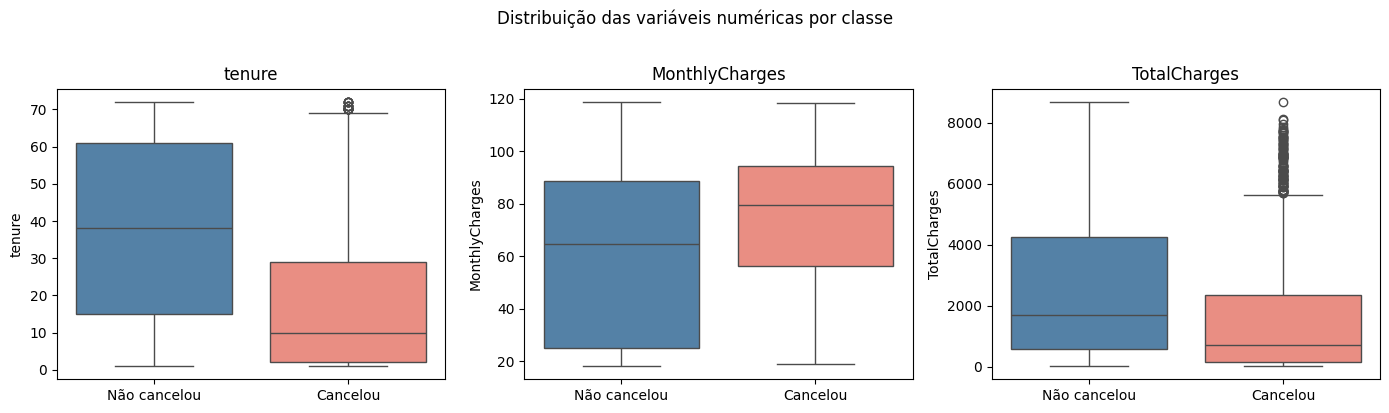

In [40]:
# vamo gerar boxplots pra visualizar a distribuição das variáveis numéricas por classes

variaveis_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i, var in enumerate(variaveis_numericas):
    sns.boxplot(x='Churn', y=var, data=df, hue='Churn', palette=['steelblue', 'salmon'], legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Não cancelou', 'Cancelou'])
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das variáveis numéricas por classe', y=1.02)
plt.tight_layout()
plt.show()


os boxplots mostram alguns pontos fora da caixa, mas todos eles fazem sentido no contexto do negócio.

a maioria está na classe "Cancelou": em tenure, há clientes com tempo de contrato alto que mesmo assim cancelaram, e em TotalCharges o mesmo padrão aparece. esses são comportamentos atípicos mas reais e remover esses valores seria perder comportamentos que podem ser informativos pro modelo, então vamo manter todos eles aí por enquanto.

analisando os resultados separadamente, dá pra concluir que:
- tenure é a variável que separa melhor as classes visualmente. quem não cancelou tem mediana em torno de 38 meses e caixa bem espalhada, variando entre 15 e 60. já quem cancelou tem mediana em torno de 10 meses e caixa concentrada na parte de baixo, variando entre 1 e 30. ou seja: clientes que cancelam são predominantemente novos, ainda no início do relacionamento com a empresa (o que faz total sentido, já que quem fica por muitos meses já passou pela fase crítica de abandono);
- MonthlyCharges também separa bem, mas em direção oposta à tenure. nesse caso, quem cancelou paga mais (com uma mediana em torno de 80, contra algo próximo de 65 de quem ficou). a caixa dos que cancelaram fica deslocada pra cima, confirmando a hipótese sobre fibra ótica e planos premium levantada nas estatísticas descritivas que diz que clientes com mensalidades mais altas têm mais motivo para reavaliar o custo-benefício;
- quem não cancelou tem TotalCharges maior, mas isso não quer dizer, necessariamente, que paga mais por mês, e sim que ficou mais tempo (tenure alto), já que TotalCharges é derivada das duas anteriores.


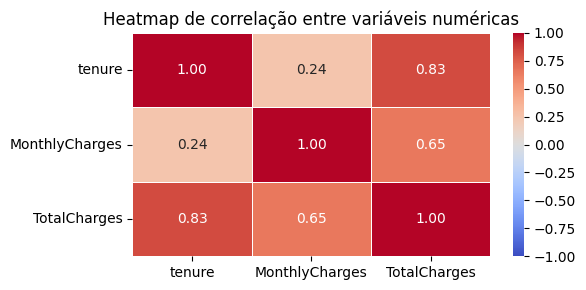

In [41]:
# vamo fazer um heatmap pra checar a correlação entre as variáveis numéricas

correlacao = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
plt.figure(figsize=(6, 3))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()


o heatmap confirma o que já era esperado: TotalCharges tem correlação alta
com tenure (0.83) e moderada com MonthlyCharges (0.65), o que faz sentido
já que ela é essencialmente um acumulado das duas. isso caracteriza multicolinearidade.

a gente já conseguiu avaliar até aqui que:
- o dataset tá besbalanceado;
- tenure e MonthlyCharges separam bem as classes mas em direções opostas;
- e que TotalCharges tem multicolinearidade alta com as outras duas.

isso já nos indica que modelos baseados em árvores são a escolha mais adequada, já que lidam melhor com essas características do que modelos lineares. vamo manter as três variáveis por enquanto e seguir com a análise
das categóricas antes de fechar essa decisão.

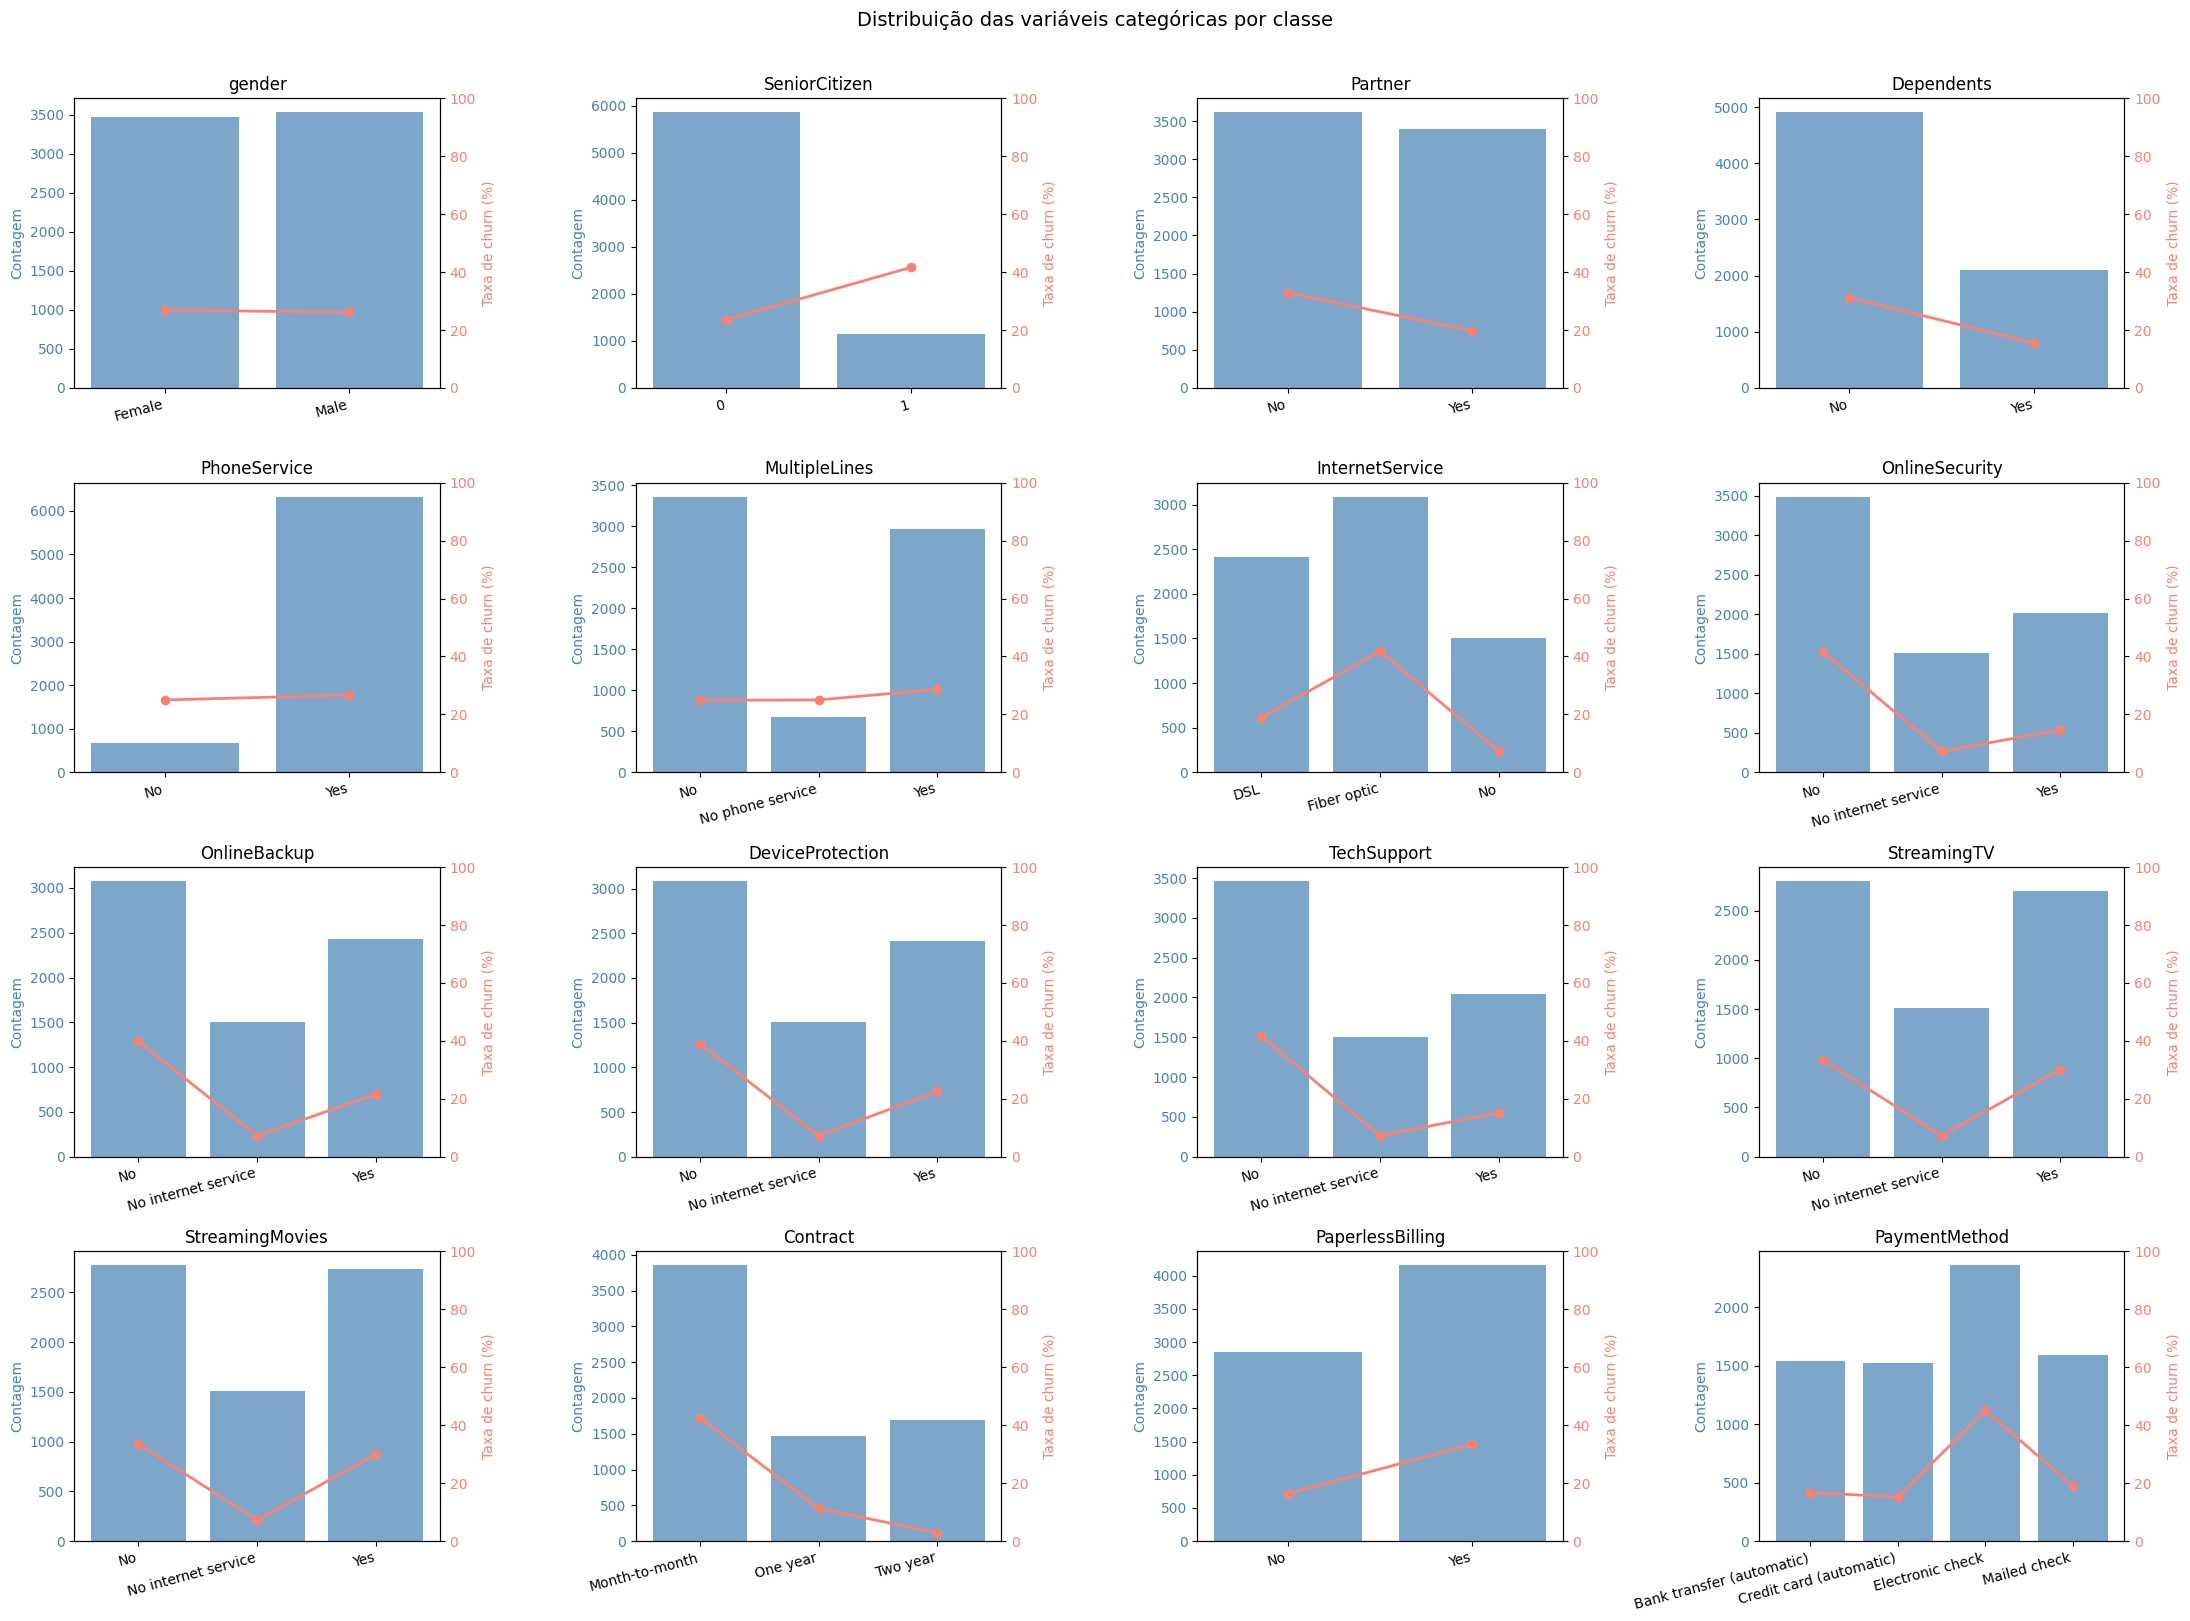

In [42]:
# agora vamo gerar gráficos duplos com barras de contagem + linha de taxa de churn sobreposta
# pra visualizar a distribuição das variáveis categóricas tbm

variaveis_categoricas = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                          'PhoneService', 'MultipleLines', 'InternetService',
                          'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                          'TechSupport', 'StreamingTV', 'StreamingMovies',
                          'Contract', 'PaperlessBilling', 'PaymentMethod']

n_cols = 4 #-> vamo colocar 4 gráficos lado a lado
n_rows = math.ceil(len(variaveis_categoricas) / n_cols)
# vamo usar o math.ceil pra garantir que o número de linhas sempre arredonde pra cima

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, var in enumerate(variaveis_categoricas):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    # vamo usar o twinx() pra conseguir sobrepor barras de contagem e linha de taxa no mesmo gráfico sem distorcer a escala de nenhum dos dois

    contagem = df.groupby(var)['Churn'].count() #-> pra fazer a contagem por categoria
    taxa = df.groupby(var)['Churn'].mean() * 100 #-> pra fazer a taxa de churn por categoria

    categorias = contagem.index.astype(str)
    x = range(len(categorias))

    ax1.bar(x, contagem.values, color='steelblue', alpha=0.7, label='Contagem')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categorias, rotation=15, ha='right')
    ax1.set_ylabel('Contagem', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2.plot(x, taxa.values, color='salmon', marker='o', linewidth=2, label='Taxa de churn (%)')
    ax2.set_ylabel('Taxa de churn (%)', color='salmon')
    ax2.tick_params(axis='y', labelcolor='salmon')
    ax2.set_ylim(0, 100) #-> pra forçar a escala da taxa de churn sempre entre 0% e 100%, tornando os gráficos comparáveis entre si

    ax1.set_title(var)
    ax1.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das variáveis categóricas por classe', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


as barras azuis mostram a contagem absoluta de clientes em cada categoria, independente de ter cancelado ou náo, e a linha laranja mostra a porcentagem de clientes daquela categoria que cancelou. ou seja: a barra responde "QUANTOS SÃO" e a linha responde "QUAL A PROPORÇÃO QUE CANCELA". a gente usou esses dois juntos, justamente, pra saber se uma categoria tem churn alto pq realmente cancela mais, ou só pq tem mais clientes.

analisando os gráficos, alguns padrões chamam atenção:
- gênero não tem influência relevante no churn. já a senioridade mostra que, apesar de idosos serem minoria na base, eles cancelam bem mais, possivelmente por terem maior sensibilidade a preço e dificuldade com tecnologia, podendo se sentir perdidos sem suporte adequado;
- clientes com parceiros ou dependentes cancelam menos, o que faz sentido, já que decisões financeiras em família geram mais inércia e o custo por pessoa em planos compartilhados é menor, então o incentivo pra ficar é maior;
- clientes com fibra ótica têm a maior taxa de churn de todo o dataset (com um pouco mais de 40%), confirmando a hipótese levantada anteriormente sobre o mercado premium ser mais disputado;
- os serviços adicionais mostram um padrão claro: quem contrata cancela menos, porque, além de ter mais engajamento com a empresa, tbm acumula mais serviços pra perder de uma vez se sair. StreamingTV e StreamingMovies seguem o mesmo padrão, mas com menos força, provavelmente porque o cliente consegue substituir esses serviços facilmente por alternativas externas.
- o gráfico de tipo de contrato confirma o que a gente já esperava: Month-to-month chega a mais de 40% de churn, One year cai pra perto de 10%, e Two year chega perto de zero. sem multa rescisória, o custo de cancelar é zero;
- clientes com fatura digital (PaperlessBilling) cancelam mais. isso pode ser explicado pq por serem mais engajados digitalmente, comparam planos com mais frequência e têm mais facilidade de cancelar, enquanto clientes com fatura em papel tendem a ser mais passivos;
- sobre o método de pagamento, pagamentos automáticos mostram menos taxas de cancelamento provavelmente pq o cliente não precisa agir pra continuar pagando,
então cancelar exige um esforço que muitos não fazem. Electronic check é manual e se o cliente já está acostumado a agir ativamente no pagamento, então cancelar é só mais uma ação.

de forma geral, o padrão que a gente percebe é que inércia é o maior fator de retenção. contrato longo, pagamento automático e múltiplos serviços contratados aumentam o custo de saída e reduzem o churn. em contrapartida, o perfil de maior risco e que precisa de mais atenção do time de retenção é: clientes novos, com contrato mensal, pagamento manual e fibra ótica.

## 3. Pré-processamento

antes de entrar no treinamento, a gente precisa preparar os dados pra que o
algoritmo consiga processar tudo corretamente. pra isso, vamo construir um Pipeline com ColumnTransformer pra cuidar de toda essa preparação de uma vez, garantindo que os parâmetros sejam aprendidos apenas nos dados de treino e aplicados separadamente no teste, sem data leakage.

- a gente já definiu que modelos baseados em árvores são a escolha mais adequada pra esse caso. e modelos baseados em árvores não são sensíveis à escala, então normalizar ou não as variáveis numéricas aqui não muda nada no resultado. mesmo assim, vamo incluir a normalização no Pipeline pq, além de ser uma boa prática, tbm já deixa ele mais robusto e preparado pra possíveis comparações futuras com outros algoritmos que sejam sensíveis a escala;
- algoritmos de ML não trabalham com strings diretamente. então, vamo precisar converter as variáveis categóricas: pras binárias (Yes/No), vamo usar OrdinalEncoder (já que o LabelEncoder não funciona direto dentro do ColumnTransformer), que converte pra 0 e 1. pras nominais com mais categorias, vamo usar OneHotEncoder, que cria uma coluna binária pra cada categoria, evitando que o modelo interprete uma ordem numérica onde não existe nenhuma.

resumindo: o ColumnTransformer vai aplicar transformações diferentes para cada grupo de colunas em paralelo, e o Pipeline vai garantir que tudo seja fitado só no treino.

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

# vamo começar separando as colunas por tipo
colunas_binarias = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'PaperlessBilling', 'SeniorCitizen']

colunas_nominais = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaymentMethod']

colunas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# antes de definir o preprocessor do Pipeline, vamo separar X e y
X = df.drop(columns=['Churn'])
y = df['Churn']


como o dataset é desbalanceado, um split puramente aleatório pode acabar colocando proporções diferentes no treino e no teste (o que distorceria tanto o treinamento quanto a avaliação do modelo), então vamo usar o split estratificado (stratify=y) pra garantir que a proporção de 26/74 entre as classes seja mantida e que o modelo treine e seja avaliado nas mesmas condições de desbalanceamento que existem nos dados reais.

In [44]:
# vamo fazer o split estratificado
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# e, por ultimo, definir o preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), colunas_numericas),
    ('bin', OrdinalEncoder(), colunas_binarias),
    ('nom', OneHotEncoder(drop='first', sparse_output=False), colunas_nominais)
])


nessa primeira fase, o objetivo é definir o preprocessor, pq o fit do Pipeline em si só vai ter utilidade quando o modelo estiver dentro dele (que não é nosso objetivo ainda). então, fitar o pipeline aqui, só com o preprocessor, não gera nenhum artefato útil pra segunda fase do projeto.

nossos resultados esperados aqui nessa primeira fase do projeto são:
- o DataFrame limpo -> 'churn_clean.csv';
- o preprocessor definido e salvo com joblib -> 'preprocessor.joblib'

na segunda fase, a gente carrega o df, carrega o preprocessor, monta o Pipeline com o modelo e fita tudo de uma vez.

In [45]:
# e, por último,  vamo salvar os arquivos resultantes dessa fase 1 no drive pra iniciar daqui na próxima fase
import os

os.makedirs('/content/drive/MyDrive/churn-intelligence/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/churn-intelligence/models', exist_ok=True)

joblib.dump(preprocessor, '/content/drive/MyDrive/churn-intelligence/models/preprocessor.joblib')
df.to_csv('/content/drive/MyDrive/churn-intelligence/data/churn_clean.csv', index=False)